# Predicting Weather with Machine Learning

This notebook demonstrates an advanced Data Science pipeline to predict temperature using sensor data (`light`, `humidity`) and time (`hour`).

**Advanced Features Included:**
- Cyclical Feature Engineering
- XGBoost Modeling
- Explainable AI (SHAP)
- Model Export for Web App

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set visualization style
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Data Loading

In [16]:
df = pd.read_csv('data/weather_data_ist.csv')
df.head()

,temperature,humidity,light,timestamp
0,26.2,81.0,0,2026-01-01 21:47:49.301000+05:30
1,26.2,81.0,0,2026-01-01 21:42:47.425000+05:30
2,26.2,81.0,0,2026-01-01 21:37:45.690000+05:30
3,26.7,81.0,0,2026-01-01 21:32:44.140000+05:30
4,26.7,80.0,0,2026-01-01 21:27:42.660000+05:30


## 2. Feature Engineering (Cyclical Time)
The `timestamp` column contains valuable time information. We extract the `hour` of the day.

**Crucially**, time is cyclical (hour 23 is next to hour 0). If we just leave it as 0-23, the model thinks they are far apart. We solve this by applying a Sine and Cosine transformation.

In [17]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')
df['hour'] = df['timestamp'].dt.hour

# Cyclical Encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24.0)

df[['hour', 'hour_sin', 'hour_cos']].head()

,hour,hour_sin,hour_cos
0,21,-0.707107,0.707107
1,21,-0.707107,0.707107
2,21,-0.707107,0.707107
3,21,-0.707107,0.707107
4,21,-0.707107,0.707107


## 3. Data Preparation

In [18]:
# Select final features and target
X = df[['light', 'humidity', 'hour_sin', 'hour_cos']]
y = df['temperature']

# Chronological split (70/30)
split_index = int(len(df) * 0.7)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 12224
Testing samples: 5240


## 4. Model Training (XGBoost)
We will use XGBoost, the industry standard for tabular data, to predict the temperature.

In [19]:
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBoost Performance:")
print("MAE:", round(mean_absolute_error(y_test, xgb_preds), 4))
print("MSE:", round(mean_squared_error(y_test, xgb_preds), 4))
print("R2 Score:", round(r2_score(y_test, xgb_preds), 4))

XGBoost Performance:
MAE: 1.0597
MSE: 1.9428
R2 Score: 0.7918


## 5. Explainable AI (SHAP)
Models shouldn't be black boxes. We will use SHAP (SHapley Additive exPlanations) to understand exactly how each feature contributes to the predictions.

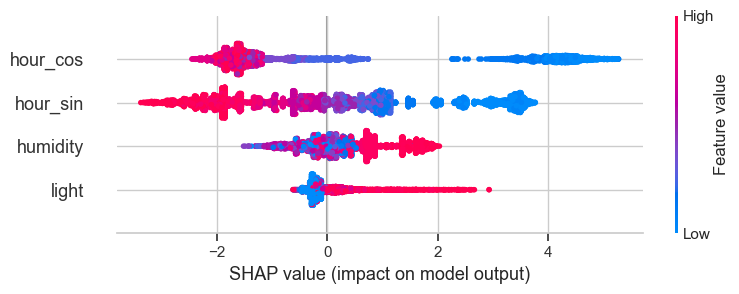

In [20]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

# Summary Plot
shap.summary_plot(shap_values, X_test)

Let's explain a single prediction. This waterfall chart shows how the model arrived at the final temperature prediction for the first test sample based on its specific sensor values.

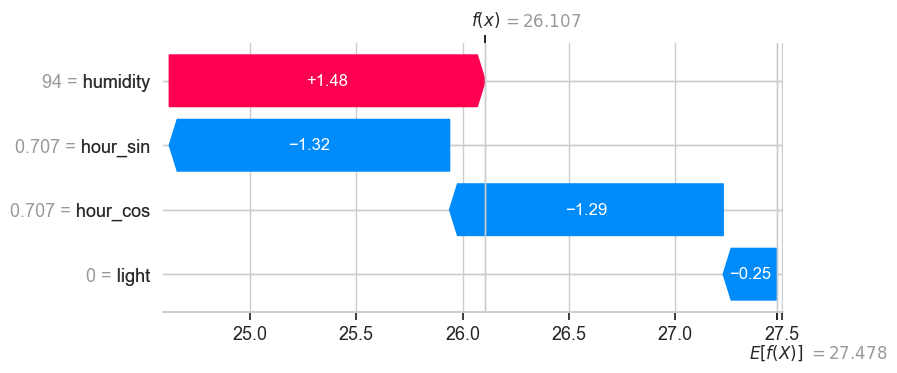

In [21]:
shap.plots.waterfall(shap_values[0])

## 6. Exporting the Model
Finally, we save the trained XGBoost model to a file so it can be used by our Streamlit web application.

In [22]:
joblib.dump(xgb_model, 'best_model.pkl')
print("Model saved to 'best_model.pkl'")

Model saved to 'best_model.pkl'
